# What effect does dt have on stochastic inertia via regime shape?
- for each dt:
    - look at epsloglog
    - define regime
    - calculate curves with markov and monte

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import cdv_utils

plt.rcParams['text.usetex'] = True
plt.rcParams['pgf.texsystem'] = "pdflatex"
plt.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath,amsfonts,amssymb,cmbright,standalone}')
importlib.reload(cdv_utils)

<module 'cdv_utils' from '/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py'>

In [2]:

from cdv_utils import (
    affinity_entry_sum, find_nearby_indices, load_d, make_L3d,
    compute_clusters_from_TO, plot_loglog_slope_analysis, find_blocking_set,
    solve_escape_from_Q, classify_new_trajectory, calculate_escape_times
)
fixed = np.array([
    [0.7285286,   0.15657308, -0.36810966, -0.32854071, -0.08004622, 0.34314342],
    [0.94484848, 0.10714876, -0.00858286, -0.71094887, -0.17206714, 0.03996197]
])

In [3]:
dt_traj = 1
sigma = 0.01
sig_max = 0.03
sig_step = 1e-4
subsample_step = 10  # <- this will be varied
dt_eff = dt_traj * subsample_step
epsilon = 2 * dt_eff * sigma**2
t_fin = int(2e4 * subsample_step)
print(epsilon)

0.002


In [4]:
n_eig = 12
n_clusters = 2
n_init = 10
eig_indices = [1, 2, 3, 4]   # zero-based eigenvector indices to use
random_state = 0
det_traj = load_d(
    "./cdv_model/data/dataOro20_sigma0p00000000.bin", 6, int(2e6))[:t_fin:subsample_step, :]


L = make_L3d(det_traj, epsilon)

In [5]:
# --- compute clusters from TO ---
det_cluster_res = compute_clusters_from_TO(L.T,
                                           n_eig=n_eig,
                                           n_clusters=n_clusters,
                                           n_init=n_init,
                                           eig_indices=eig_indices,
                                           random_state=random_state)

labels = det_cluster_res["labels"].copy()

In [6]:
blocking_idx = find_blocking_set(det_traj[:-1], labels)
blocking_mask = np.nonzero(labels == blocking_idx)[0]
entries = np.where(
    (labels[:-1] != blocking_idx) & (labels[1:] == blocking_idx))[0]+1
indices_in_reduced = np.nonzero(labels == blocking_idx)[0].searchsorted(
    entries[np.isin(entries, np.nonzero(labels == blocking_idx)[0])])

/tmp/ipykernel_19643/632097661.py:5: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed[0, 0], fixed[0, 5], c='black', s=64, alpha=1,
/tmp/ipykernel_19643/632097661.py:7: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed[1, 0], fixed[1, 5], c='red', s=64, alpha=1,


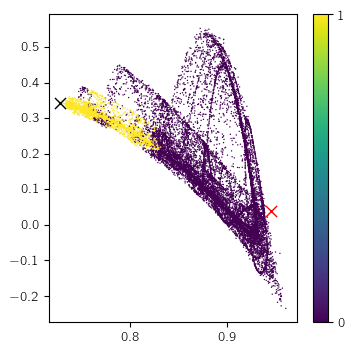

In [7]:
plt.figure(figsize=(4, 4))
sc = plt.scatter(det_traj[:-1, 0], det_traj[:-1, 5],
                 c=(labels == blocking_idx), s=1, linewidth=0, label='Clusters',
                 rasterized=True)
plt.scatter(fixed[0, 0], fixed[0, 5], c='black', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")
plt.scatter(fixed[1, 0], fixed[1, 5], c='red', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")

cbar = plt.colorbar(sc, ticks=range(len(np.unique(det_cluster_res["labels"]))))
cbar.set_ticklabels(range(len(np.unique(det_cluster_res["labels"]))))
plt.savefig(
    f"../../Sets_subsample{subsample_step}_sigma_{sigma:.3f}.pdf", bbox_inches="tight", dpi=600)

In [39]:
sigmas_loglog = np.logspace(-4, 0, 50)
eps_vals = 2.0 * dt_eff * sigmas_loglog**2

# for all points
sums_all = np.array([affinity_entry_sum(det_traj, eps, chunk=1000)
                     for eps in eps_vals]) / det_traj.shape[0]**2

# for blocking set
eps_max = 2.0 * dt_eff * sig_max**2
points = find_nearby_indices(
    det_traj, labels, eps=eps_max, regime=blocking_idx)
sums_block = np.array([affinity_entry_sum(det_traj[points], eps, chunk=1000)
                       for eps in eps_vals]) / det_traj[points].shape[0]**2

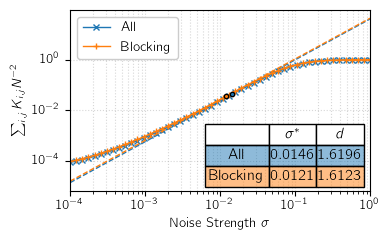

In [40]:
fig, ax = plot_loglog_slope_analysis(sigmas_loglog, sums_all, sums_block)

In [ ]:
# 90 min
t_escape_dict = {}
for sig in np.arange(0, sig_max + sig_step, sig_step):
    eps = (2 * dt_eff * sig**2)
    print(f"Processing epsilon = {eps:.6f}")

    L = make_L3d(det_traj, eps)
    Q = L[labels == blocking_idx][:,
                                  labels == blocking_idx].tocsr()
    t_escape = solve_escape_from_Q(Q)

    # Store
    t_escape_dict[eps] = t_escape

Processing epsilon = 0.000000
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=4320, density=0.0001736).
Processing epsilon = 0.000000
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=58705, density=0.002359).
Processing epsilon = 0.000001
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=141210, density=0.005673).
Processing epsilon = 0.000002
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=238715, density=0.009591).
Processing epsilon = 0.000003
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=346202, density=0.01391).
Processing epsilon = 0.000005
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=464791, density=0.01867).
Processing epsilon = 0.000007
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=590575, density=0.02373).
Processing epsilon = 0.000010
[iterative] GMRES converged with ILU preconditioner (n=4989, nnz=716895, density=0.0288).
Processing epsilon = 0.000013
[

In [ ]:
# 20 min
import glob
import re

escape_results = {}  # plain dict
for fname in sorted(glob.glob("./cdv_model/data/dataOro20_sigma0p*.bin")):
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace(
        "p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)
    if sigma_val > sig_max:
        break
    print(f"Processing sigma={sigma_val}")

    sig_data = load_d(fname, 6, int(2e6))[::subsample_step, :]

    # classify
    labels_new = classify_new_trajectory(
        det_traj[:-1], labels, sig_data, k=20, threshold=0.5
    )

    esc_dict = calculate_escape_times(labels_new, dt=dt_eff)

    # insert into dict safely
    for regime, times in esc_dict.items():
        if regime not in escape_results:
            escape_results[regime] = {}
        if sigma_val not in escape_results[regime]:
            escape_results[regime][sigma_val] = []
        escape_results[regime][sigma_val].extend(times)

Processing sigma=0.0
Processing sigma=0.0001
Processing sigma=0.0002
Processing sigma=0.0003
Processing sigma=0.0004
Processing sigma=0.0005
Processing sigma=0.0006
Processing sigma=0.0007
Processing sigma=0.0008
Processing sigma=0.0009
Processing sigma=0.001
Processing sigma=0.0011
Processing sigma=0.0012
Processing sigma=0.0013
Processing sigma=0.0014
Processing sigma=0.0015
Processing sigma=0.0016
Processing sigma=0.0017
Processing sigma=0.0018
Processing sigma=0.0019
Processing sigma=0.002
Processing sigma=0.0021
Processing sigma=0.0022
Processing sigma=0.0023
Processing sigma=0.0024
Processing sigma=0.0025
Processing sigma=0.0026
Processing sigma=0.0027
Processing sigma=0.0028
Processing sigma=0.0029
Processing sigma=0.003
Processing sigma=0.0031
Processing sigma=0.0032
Processing sigma=0.0033
Processing sigma=0.0034
Processing sigma=0.0035
Processing sigma=0.0036
Processing sigma=0.0037
Processing sigma=0.0038
Processing sigma=0.0039
Processing sigma=0.004
Processing sigma=0.0041

In [8]:
import pickle
# with open(f"subsample_{subsample_step}_lifetimes_sigma_{sigma}.pkl", "wb") as f:
#     pickle.dump((escape_results, t_escape_dict), f)
with open(f"subsample_{subsample_step}_lifetimes_sigma_{sigma}.pkl", "rb") as f:
    escape_results, t_escape_dict = pickle.load(f)

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_19643/2139439322.py:14: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")


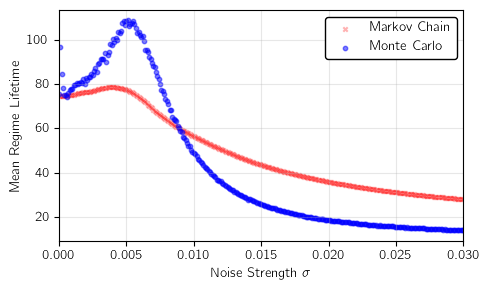

In [9]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(np.sqrt(np.array(sorted(t_escape_dict.keys())) / (dt_eff*2)),
           np.array([t_escape_dict[k][indices_in_reduced].mean()
                     for k in sorted(t_escape_dict.keys())]) * dt_eff,
           label=f'Markov Chain', alpha=.3, s=10,  marker="x", color='red')
means = np.array([np.mean(v)
                  for k, v in sorted(escape_results[blocking_idx].items())])
ax.scatter(sorted(escape_results[blocking_idx].keys()), means,
           label=f'Monte Carlo', marker="o", color='blue', s=10, alpha=.5)
# means_fine = np.array([np.mean(v)
#                   for k, v in sorted(escape_results_fine[0].items())])
# ax.scatter(sorted(escape_results_fine[0].keys()), means_fine,
#            label=f'Monte Carlo fine', marker="s", color='darkgreen', s=10, alpha=.5)
ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Mean Regime Lifetime")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, sig_max)

ax.legend(facecolor='white', edgecolor='black', loc='best', framealpha=1)
plt.tight_layout()
# plt.savefig(f"../../CdV_MeanRegimeLifetimeComparison_subsample_{subsample_step}_sigma_{sigma}.pdf",
#             dpi=600, bbox_inches="tight")

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_15749/2151934034.py:14: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("Noise Strength $\sigma$")


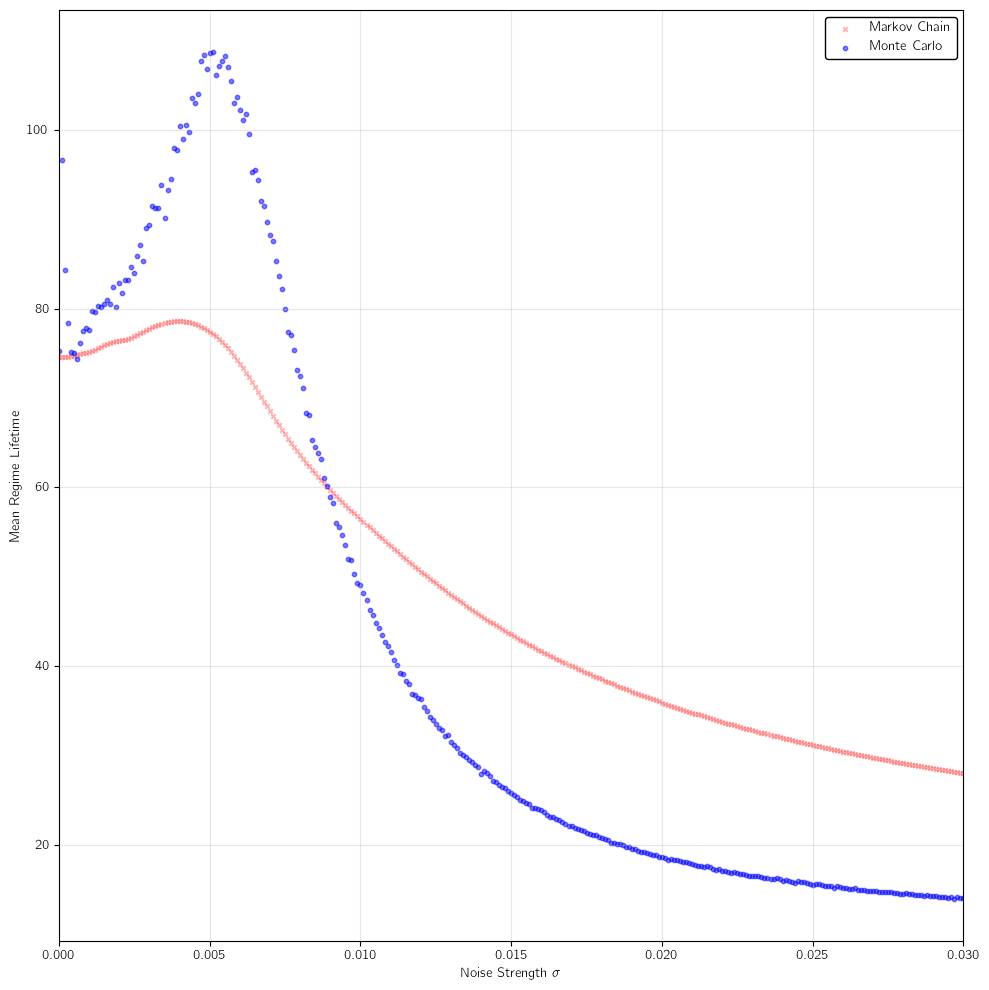

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(np.sqrt(np.array(sorted(t_escape_dict.keys())) / (dt_eff*2)),
           np.array([t_escape_dict[k][indices_in_reduced].mean()
                     for k in sorted(t_escape_dict.keys())]) * dt_eff,
           label=f'Markov Chain', alpha=.3, s=10,  marker="x", color='red')
means = np.array([np.mean(v)
                  for k, v in sorted(escape_results[blocking_idx].items())])
ax.scatter(sorted(escape_results[blocking_idx].keys()), means,
           label=f'Monte Carlo', marker="o", color='blue', s=10, alpha=.5)
ax.set_xlabel("Noise Strength $\sigma$")
ax.set_ylabel("Mean Regime Lifetime")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, sig_max)

ax.legend(facecolor='white', edgecolor='black', loc='best', framealpha=1)
plt.tight_layout()

In [14]:
import glob
import re
sigs = []
for fname in sorted(glob.glob("./cdv_model/data/dataOro20_sigma0p*.bin")):
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace(
        "p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)
    sigs.append(sigma_val)

# EPSLOGLOG Compare

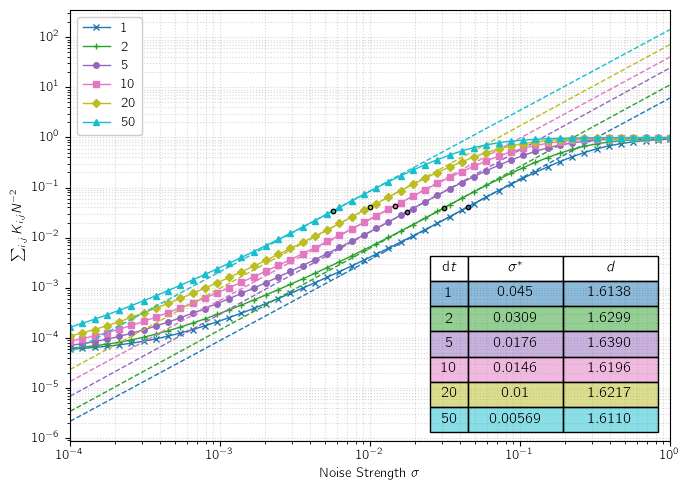

In [7]:
import pickle
from itertools import cycle
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

with open("./subsample_sums.pkl", "rb") as f:
    sums = pickle.load(f)
sigmas_loglog = np.logspace(-4, 0, 50)

logx = np.log10(sigmas_loglog)
subsample_steps = [1, 2, 5, 10, 20, 50]  # <- this will be varied
keys = sorted(sums.keys())
n = len(keys)
cmap = plt.get_cmap('tab10')
colors = [cmap(i / (n - 1)) for i in range(n)]

# markers to cycle through if more datasets than original two
marker_list = ['x', '+', 'o', 's', 'D', '^', 'v', '<', '>', '*']
marker_cycle = cycle(marker_list)

logx = np.log10(sigmas_loglog)
fig, ax = plt.subplots(figsize=(7, 5))
x_line_log = np.linspace(logx[0], logx[-1], 300)
table_rows = []

# plot datasets and slope-lines
for idx, key in enumerate(keys):
    sum_i = np.asarray(sums[key])
    col = colors[idx]
    m = next(marker_cycle)
    logy = np.log10(sum_i)

    # local slopes between consecutive log points
    slopes = np.diff(logy) / np.diff(logx)
    imax = int(np.argmax(slopes))
    slope_max = slopes[imax]

    # geometric mean location for sigma* (between imax and imax+1)
    sig_at_max = np.sqrt(sigmas_loglog[imax] * sigmas_loglog[imax + 1])

    # anchor: midpoint in log space
    logx_mid = 0.5 * (logx[imax] + logx[imax + 1])
    logy_mid = 0.5 * (logy[imax] + logy[imax + 1])

    # line (in log space) anchored at midpoint
    y_line_log = slope_max * (x_line_log - logx_mid) + logy_mid

    # main curve: log-log
    ax.loglog(sigmas_loglog, sum_i, '-', color=col, marker=m,
              markersize=4, linewidth=1,
              label=str(key), markevery=1)
    ax.loglog(10 ** x_line_log, 10 ** y_line_log, '--', color=col,
              linewidth=1, alpha=1)

    # point of maximum slope: same colour
    y_at_max = 10 ** logy_mid  # anchored midpoint value
    ax.scatter([sig_at_max], [y_at_max], color=col, edgecolor='k',
               s=(2 * 5), zorder=10)

    # accumulate row for the summary table (first column is the integer key)
    table_rows.append((str(key), f"{sig_at_max:.3g}", f"{slope_max:.4f}"))

ax.set_xlim(sigmas_loglog[0], sigmas_loglog[-1])
ax.set_xlabel(r'Noise Strength $\sigma$')
ax.set_ylabel(r'$\sum_{i,j} K_{i,j} N^{-2}$')
ax.grid(True, which='both', ls=':', alpha=0.5)

# Legend: ensure marker+colour shown exactly as plotted
legend_handles = []
# Rebuild markers in the same order used above
# (recreate a fresh cycle so marker assignment matches plotting order)
marker_cycle = cycle(marker_list)
for idx, key in enumerate(keys):
    col = colors[idx]
    m = next(marker_cycle)
    legend_handles.append(Line2D([0], [0], color=col, marker=m, lw=1,
                                 markersize=4, label=str(key)))
ax.legend(handles=legend_handles, framealpha=1)

# Small table with results: place inside axes (bottom-right)
col_labels = (r"$\mathrm{d}t$", r"$\sigma^\ast$", r"$d$")
cell_text = [row for row in table_rows]

# make the table height scale with number of rows (keep it reasonable)
table_height = min(0.45, 0.06 + 0.05 * (n + 1))  # +1 accounts for header
bbox = [0.6, 0.02, 0.38, table_height]

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='center',
    colLoc='center',
    bbox=bbox,  # bottom-right corner area
    edges='closed',
    colWidths=[0.1, 0.25, 0.25]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.set_zorder(10)

# Header: white and bold
for c in range(3):
    cell = tbl[(0, c)]
    cell.set_facecolor((1, 1, 1, 1))
    cell.set_text_props(weight='bold')

# Data rows: tinted by dataset colour
for r, col in enumerate(colors, start=1):
    rgba = list(to_rgba(col))
    rgba[3] = 0.5  # transparency for table row background
    for c in range(3):
        tbl[(r, c)].set_facecolor(rgba)

# Tidy up
plt.tight_layout()

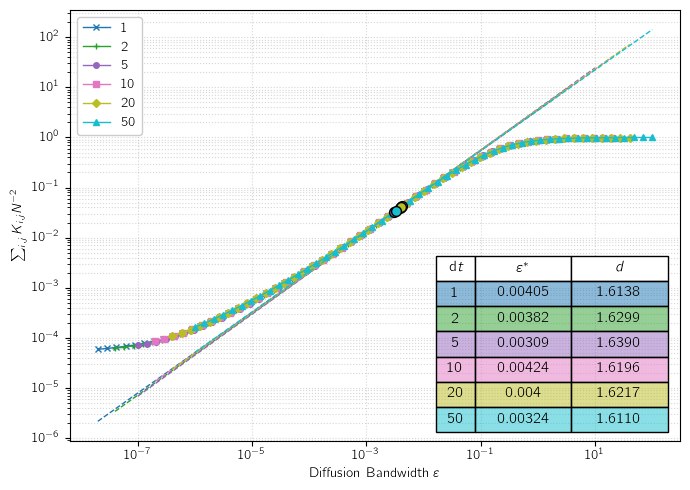

In [11]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

with open("./subsample_sums.pkl", "rb") as f:
    sums = pickle.load(f)

sigmas_loglog = np.logspace(-4, 0, 50)

keys = sorted(sums.keys())  # dt values
n = len(keys)

cmap = plt.get_cmap('tab10')
colors = [cmap(i / (n - 1)) for i in range(n)]

marker_list = ['x', '+', 'o', 's', 'D', '^', 'v', '<', '>', '*']
marker_cycle = cycle(marker_list)

fig, ax = plt.subplots(figsize=(7, 5))
table_rows = []

# plot datasets and slope-lines
for idx, dt in enumerate(keys):
    sum_i = np.asarray(sums[dt])
    col = colors[idx]
    m = next(marker_cycle)

    # --- sigma -> epsilon transform ---
    eps = 2.0 * dt * sigmas_loglog**2

    logx = np.log10(eps)
    logy = np.log10(sum_i)

    # local slopes in log–log epsilon space
    slopes = np.diff(logy) / np.diff(logx)
    imax = int(np.argmax(slopes))
    slope_max = slopes[imax]
    d_max = slope_max*2
    # geometric mean epsilon*
    eps_at_max = np.sqrt(eps[imax] * eps[imax + 1])

    # anchor midpoint in log space
    logx_mid = 0.5 * (logx[imax] + logx[imax + 1])
    logy_mid = 0.5 * (logy[imax] + logy[imax + 1])

    # reference slope line
    x_line_log = np.linspace(logx[0], logx[-1], 300)
    y_line_log = slope_max * (x_line_log - logx_mid) + logy_mid

    # main curve
    ax.loglog(
        eps, sum_i,
        '-', color=col, marker=m,
        markersize=4, linewidth=1,
        label=str(dt), markevery=1
    )

    # slope line
    ax.loglog(
        10 ** x_line_log, 10 ** y_line_log,
        '--', color=col, linewidth=1
    )

    # max-slope point
    ax.scatter(
        [eps_at_max], [10 ** logy_mid],
        color=col, edgecolor='k',
        s=50, zorder=10
    )

    # table row
    table_rows.append((str(dt), f"{eps_at_max:.3g}", f"{d_max:.4f}"))

# axis formatting
ax.set_xlabel(r'Diffusion Bandwidth $\varepsilon$')
ax.set_ylabel(r'$\sum_{i,j} K_{i,j} N^{-2}$')
ax.grid(True, which='both', ls=':', alpha=0.5)

# legend (marker + color preserved)
legend_handles = []
marker_cycle = cycle(marker_list)
for idx, dt in enumerate(keys):
    legend_handles.append(
        Line2D([0], [0], color=colors[idx],
               marker=next(marker_cycle),
               lw=1, markersize=4, label=str(dt))
    )

ax.legend(handles=legend_handles, framealpha=1)

# summary table
col_labels = (r"$\mathrm{d}t$", r"$\varepsilon^\ast$", r"$d$")
table_height = min(0.45, 0.06 + 0.05 * (n + 1))
bbox = [0.6, 0.02, 0.38, table_height]

tbl = ax.table(
    cellText=table_rows,
    colLabels=col_labels,
    cellLoc='center',
    colLoc='center',
    bbox=bbox,
    edges='closed',
    colWidths=[0.1, 0.25, 0.25]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.set_zorder(10)

# header styling
for c in range(3):
    cell = tbl[(0, c)]
    cell.set_facecolor((1, 1, 1, 1))
    cell.set_text_props(weight='bold')

# row coloring
for r, col in enumerate(colors, start=1):
    rgba = list(to_rgba(col))
    rgba[3] = 0.5
    for c in range(3):
        tbl[(r, c)].set_facecolor(rgba)

plt.tight_layout()